# Building a Neural Network to Approximate Gordon Riley's 1946 phytoplankton model

### Plan: NN and PINN for the phytoplankton model presented in Gordon Riley's 1946 paper 

1. **Standard Neural Network** trained only on data.
2. **Physics-Informed Neural Network (PINN)** trained on data *and* the phytoplankton ODE.

---

### Implement neural networks to emulate Riley's 1946 phytoplankton model

Riley (1946) "Factors controlling phytoplankton populations on Georges Bank" is available [online](https://elischolar.library.yale.edu/journal_of_marine_research/624/).

The ODE presented in Riley (1946) is:

$$
\frac{dP}{dt} = P\left(P_h - R - G\right)
$$

Where:

* $P_h = p \, \frac{I_0}{k z_1} \, (1 - e^{-k z_1}) \, (1 - N) \, (1 - V)$: phytoplankton growth/increase
* $R = R_0 \, e^{r T}$: temperature-dependent respiration
* $G = g \, Z$: zooplankton grazing

We use the measurements reported in Riley (1946) to train

* a NN to learn $P(t)$, $Z(t)$ and $P_h(t)/p$, $R(t)/R_0$
* a PINN that minimizes both data loss and residual of the ODE and optionally estimates the parameters $p$, $R_0$, and $G$ that scale the 3 source and sink terms

The 4 terms $P(t)$, $Z(t)$ and $P_h(t)/p$, $R(t)/R_0$ were measured or estimated based on measurements from surveys conducted on Georges Bank over the course of several years. The data are meant to represent a climatological seasonal cycle. Estimates for the  $p$, $R_0$, and $G$ are presented in Riley (1946) along with those for a few other parameters. Here, we simplify things a bit by only considering 4 model state variables ($P(t)$, $Z(t)$, $P_h(t)/p$, and $R(t)/R_0$) and 3 scaling parameters. In Riley (1946), $P_h(t)$, and $R(t)$ are made up of other state estimates and additional parameters that we aggregate here. However, the data files contain all state estimates recorded in the paper, so a more detailed analysis is possible.

In [1]:
import pandas as pd

import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt

seed = 42
# optional: introduce noise to the initial parameter estimates
relerror_param = 0.0
# if set to True, estimate the phytoplankton model parameters with the PINN
# otherwise keep them at the Riley (1946) values, modified by relerror_param above
estimate_parameters = False

I0000 00:00:1777156523.548162   50114 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777156523.593576   50114 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777156524.830753   50114 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### Helper functions for plotting an data normalization

In [2]:
# define the colors of state variables
colors_var = {'P': 'seagreen', 'Z': 'lightcoral', 'growth limit': 'C0', 'respiration temp effect': 'C1'}

# These alternative functions can be used when the NN is build without the softplus function in the last layer 
# that requires positive state values.

#def norm_state(state):
#    return (state - norm_weights['mean']) / norm_weights['std']

#def denorm_state(state):
#    return state * norm_weights['std'] + norm_weights['mean']

def norm_state(state):
    return state / (0.1 * norm_weights['max'])

def denorm_state(state):
    return state * (0.1 * norm_weights['max'])

def plot_result(t_data, state_data, t_est, state_est_normed, epoch=None, data_label='training data', model_label='NN', 
                show=False):

    state_est = denorm_state(state_est_normed)

    fig, axs = plt.subplots(figsize=(10, 8), nrows=2, sharex=True, gridspec_kw={'height_ratios': (2, 1), 'hspace': 0.03})
    ax_twin = axs[1].twinx()
    axs_var = {'P': axs[0], 'Z': axs[0], 'growth limit': axs[1], 'respiration temp effect': ax_twin}
    
    axs[-1].set(xlabel='day of year')
    axs_var['P'].set(ylabel='biomass (g C m$^{-2}$)')
    for var in ('growth limit', 'respiration temp effect'):
        axs_var[var].set_ylabel(var, color=colors_var[var])
    
    for istate, var in enumerate(('P', 'Z', 'growth limit', 'respiration temp effect')):
        color = colors_var[var]
        ax = axs_var[var]
        ax.plot(np.asarray(t_est), np.asarray(state_est[:, istate]), color=color, label=f'{var} {model_label} estimate')
        
        ax.plot(t_data, state_data[:, istate], color=color, ls='none', marker='o', label=f'{var} {data_label}')

    title = None
    if epoch is not None:
        title = f'{model_label} epoch {epoch}'
    axs_var['P'].legend(title=title)
    
    for ax in axs:
        ax.grid(True)
    
    if show:
        plt.show()
    return axs

### Loading data

The default code loads `Riley1946_measurements_extended.csv` which contains measurements and other "extended" data such as Riley's solution for phytoplankton `Pt` and its time-derivative `dP_dt` at the 6 times (days of year) reported in the paper.
Alternatively, `Riley1946_data-points.csv` provides most of these variables at a higher time resolution based on the interpolations presented in Riley (1946) and its appendix. The observed phytoplankton (`Pobs`) are not available at that higher time resolution, so Riley's solution (`Pt`) is used in the training data instead. 

In [3]:
data = pd.read_csv('data/Riley1946_measurements_extended.csv')
# higher-density dataset from interpolations introduced in Riley (1946)
#data = pd.read_csv('data/Riley1946_data-points.csv')

p_key = 'Pobs'
if p_key not in data.columns:
    # for denser data, use Riley's interpolated solution for phytoplankton
    p_key = 'Pt'

In [4]:
data

,day,I_0,k,z1,one_minus_N,z2,one_minus_V,Ph,T,RT,Z,G,dP_dt,lnPt_minus_lnP0,lnPt,Pt,secchi,Pobs
0,8,0.090390,0.120810,34.026949,1.00,53.0,0.636821,0.034755,4.6,0.023366,1.44,0.010356,0.001033,0.014872,1.231826,3.453896,14.0,2.0
1,89,0.243180,0.155095,32.559478,1.00,35.0,0.988926,0.117238,2.7,0.021045,7.15,0.055322,0.040871,1.627636,2.844452,17.013467,11.0,14.0
2,114,0.282788,0.211366,24.099034,0.97,19.0,0.997087,0.131034,4.0,0.022537,10.00,0.101710,0.006786,2.281064,3.498014,32.733756,8.0,39.5
3,135,0.306000,0.170000,31.000000,0.93,18.0,1.000000,0.132000,5.6,0.026000,19.15,0.145000,-0.039000,1.440000,2.657000,14.200000,10.0,15.0
4,175,0.325653,0.169636,32.172397,0.84,10.0,0.999985,0.128515,10.9,0.036444,7.45,0.071376,0.020696,1.040663,2.257663,9.738017,10.0,8.0
5,256,0.233021,0.154927,32.827725,0.59,12.0,0.999982,0.067653,16.5,0.054336,4.60,0.034563,-0.021246,0.641308,1.858308,6.372433,11.0,9.5


### Creating the state matrix/training data

In [5]:
kz1 = data['k'].values * data['z1'].values
# P_h term but without including multiplication with parameter p
growth_limit = data['I_0'].values/kz1 * (1.0 - np.exp(-kz1)) * data['one_minus_N'].values * data['one_minus_V'].values
# R term but without including multiplication with parameter R_0
respiration_temp_effect = np.exp(0.069*data['T'].values)
# G term without including multiplication with parameter g
zooplankton = data['Z'].values

t_obs = data['day'].values
state_obs = np.concatenate([data[p_key].values[:,None], zooplankton[:,None], growth_limit[:,None], respiration_temp_effect[:,None]], axis=1)

In [6]:
state_obs

array([[2.00000000e+00, 1.44000000e+00, 1.37731367e-02, 1.37355188e+00],
       [1.40000000e+01, 7.15000000e+00, 4.73175480e-02, 1.20478364e+00],
       [3.95000000e+01, 1.00000000e+01, 5.33651977e-02, 1.31784786e+00],
       [1.50000000e+01, 1.91500000e+01, 5.37222450e-02, 1.47167322e+00],
       [8.00000000e+00, 7.45000000e+00, 4.99081313e-02, 2.12145039e+00],
       [9.50000000e+00, 4.60000000e+00, 2.68643219e-02, 3.12208173e+00]])

### Initializing the parameters with the values from Riley (1946)

In [7]:
parameters = {
    'p':   2.5,     # photosythetic constant (page 62)
    'R0':  0.0175,  # respiration rate at 0 °C (page 66)
    'g':   0.0075,  # rate of reduction of phytoplankton by a unit quantity of animals (page 67)
}

### Creating Tensorflow tensors from data and other preparation

In [8]:
t_train = t_obs
state_train = state_obs

# optional: copy data to from first point to last day to create semblance of periodicity
t_train = np.concatenate([t_obs, [365]])
state_train = np.concatenate([state_obs, state_obs[0,:][None,:]])

# alternative option: set first and last points to create periodicity
#t_train = np.concatenate([[0], t_obs, [365]])
#state_train = np.concatenate([state_obs[0,:][None,:], state_obs, state_obs[0,:][None,:]])

t_full = np.arange(365.0)

t_train_tensor = tf.constant(t_train, dtype=tf.float32)[:, None]
state_train_tensor = tf.constant(state_train, dtype=tf.float32)

t_full_tensor = tf.constant(t_full, dtype=tf.float32)[:, None]

# compute the weights needed in helper functions
norm_weights = {
    'mean': tf.reduce_mean(state_train_tensor, axis=0)[None, :],
    'std': tf.math.reduce_std(state_train_tensor, axis=0)[None, :],
    'max': tf.math.reduce_max(state_train_tensor, axis=0)[None, :],
}

state_train_tensor = norm_state(state_train_tensor)
state_train_tensor

E0000 00:00:1777156525.932113   50114 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<tf.Tensor: shape=(7, 4), dtype=float32, numpy=
array([[ 0.5063291 ,  0.75195825,  2.563768  ,  4.399474  ],
       [ 3.5443037 ,  3.7336817 ,  8.807814  ,  3.8589113 ],
       [10.        ,  5.2219324 ,  9.933538  ,  4.221055  ],
       [ 3.7974684 , 10.        , 10.        ,  4.713756  ],
       [ 2.0253165 ,  3.8903394 ,  9.290031  ,  6.7949867 ],
       [ 2.4050632 ,  2.4020889 ,  5.0005956 , 10.        ],
       [ 0.5063291 ,  0.75195825,  2.563768  ,  4.399474  ]],
      dtype=float32)>

## Building a neural network

In [9]:
def build_nn(num_hidden_layers, num_hidden_units, dim_input=1, dim_output=4,
             loss=None, add_final_softplus=True):
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(dim_input,)))
    for _ in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(num_hidden_units, activation='gelu'))
    if add_final_softplus:
        model.add(tf.keras.layers.Dense(dim_output, activation='softplus'))
    else:
        model.add(tf.keras.layers.Dense(dim_output))
    if loss is not None:
        model.compile(optimizer='adam', loss=loss)
    return model

def mse(obs, est):
    return tf.reduce_mean((obs - est)**2)

starting NN training...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
(365, 4)


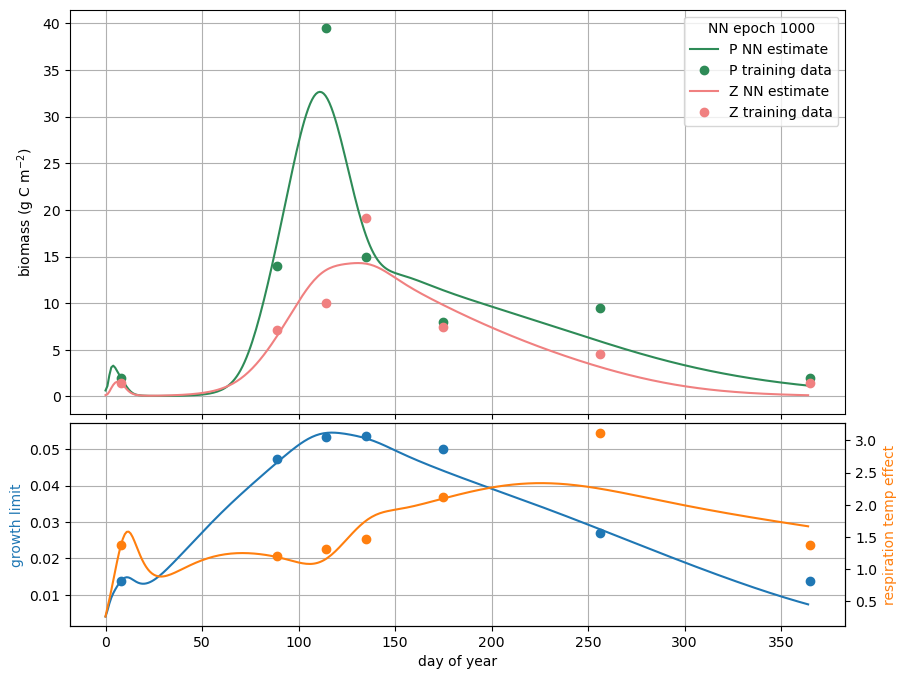

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
(365, 4)


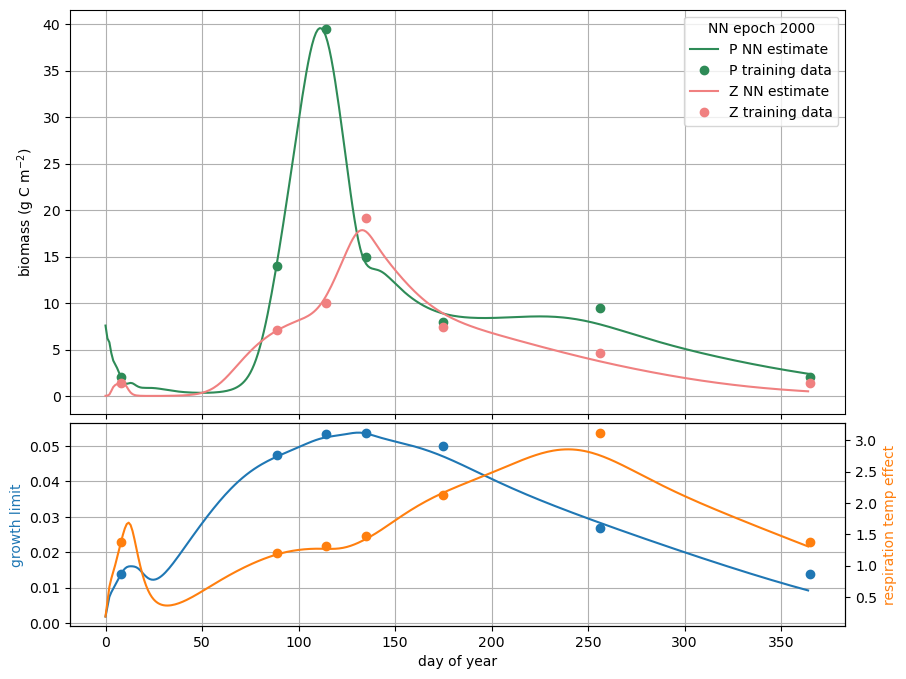

In [10]:
np.random.seed(seed)
tf.random.set_seed(seed)

use_fit = False

model_label = 'NN'
print(f'starting {model_label} training...')
if use_fit:
    model_nn = build_nn(num_hidden_layers=3, num_hidden_units=64, loss=mse)
    history = model_nn.fit(
        t_train_tensor, state_train_tensor,
        epochs=3_000,
        verbose=0,
    )

    state_est = model_nn.predict(t_full_tensor)
    plot_result(t_train, state_train, t_full, state_est, model_label=model_label)
else:
    model_nn = build_nn(num_hidden_layers=3, num_hidden_units=64)
    epochs = 2_000

    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    for epoch in range(1, epochs + 1):
        with tf.GradientTape() as tape:
            state_train_est = model_nn(t_train_tensor)
            loss = mse(state_train_tensor, state_train_est)
        grads = tape.gradient(loss, model_nn.trainable_variables)
        optimizer.apply_gradients(zip(grads, model_nn.trainable_variables))

        if epoch % 1_000 == 0:
            state_est = model_nn.predict(t_full_tensor)
            print(state_est.shape)
            plot_result(t_train, state_train, t_full, state_est, epoch=epoch, model_label=model_label, show=True)
None

In [11]:
def pinn_loss(model, t_obs, state_obs, t_dyn, parameters, weight_dyn=0.1):
    
    # compute data loss
    
    state_est = model(t_obs)
    loss_data = mse(state_train_tensor, state_est)
    
    # compute dynamics loss

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t_dyn)
        state_dyn_pred = denorm_state(model(t_dyn))

        P = state_dyn_pred[:, 0:1]
        Z = state_dyn_pred[:, 1:2]
        growth = state_dyn_pred[:, 2:3]
        respiration = state_dyn_pred[:, 3:4]

    dPdt = tape.gradient(P, t_dyn)
    
    # use learned parameters
    dPdt_params = P * (parameters['p'] * growth - parameters['R0'] * respiration - parameters['g'] * Z)
    
    loss_dyn = weight_dyn * tf.reduce_mean((dPdt - dPdt_params)**2)
    
    loss_total = loss_data + loss_dyn
    
    return loss_total, loss_data, loss_dyn


def train_pinn(parameters, estimate_parameters=False, epochs=10_000, report_interval=2_000, 
               num_hidden_layers=3, num_hidden_units=64, 
               learning_rate=1e-3, model_label='PINN'):
    tf.random.set_seed(seed)
    loss_terms = ('total', 'data', 'dynamics')
    
    t_dyn = tf.constant(t_full, dtype=tf.float32)[:, None]
    
    model_pinn = build_nn(num_hidden_layers=num_hidden_layers, num_hidden_units=num_hidden_units)
    
    if estimate_parameters:
        # group parameters for optimizer, create Tensorflow variables for the parameters and add them to learnable parameters
        parameters_pinn = {k: tf.Variable(parameters[k], type=tf.float32) for k, v in parameters.items()}
        learnable_params = model_pinn.trainable_variables + list(parameters_pinn.values())
    else:
        # if parameters are not estimated, keep them as constants
        parameters_pinn = {k: tf.constant(parameters[k]) for k, v in parameters.items()}
        learnable_params = model_pinn.trainable_variables
    
    pinn_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  #, epsilon=1e-8)

    loss_history = {k: np.full(epochs, fill_value=np.nan) for k in loss_terms}

    weight_dyn = 0.1
    for epoch in range(1, epochs+1):
        weight_dyn = 10**((1.0-epoch/epochs) * np.log10(0.0001) + (epoch/epochs) * np.log10(3.0))
        with tf.GradientTape() as tape:
            losses = pinn_loss(model_pinn, t_train_tensor, state_train_tensor, t_dyn, parameters_pinn, weight_dyn=weight_dyn)

        grads = tape.gradient(losses[0], learnable_params)
        pinn_optimizer.apply_gradients(zip(grads, learnable_params))

        for iloss, key in enumerate(loss_terms):
            loss_history[key][epoch-1] = losses[iloss].numpy()
        
        if epoch % report_interval == 0:
            ll = [loss_history[k][epoch-1] for k in loss_terms]
            status_str = f'epoch {epoch} (weight_dyn={weight_dyn:.4f}): total loss: {ll[0]:.6f}'
            status_str += '({})'.format(', '.join([f' {k} loss: {l:.6f} [{l/ll[0]:.1%}]' for k, l in zip(loss_terms[1:], ll[1:])]))
            print(status_str)

            state_est = model_pinn.predict(t_full_tensor)
            plot_result(t_train, state_train, t_full, state_est, epoch=epoch, model_label=model_label, show=True)

    return model_pinn, loss_history, parameters_pinn

starting PINN training...
epoch 2000 (weight_dyn=0.0008): total loss: 0.405492( data loss: 0.405328 [100.0%],  dynamics loss: 0.000164 [0.0%])
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


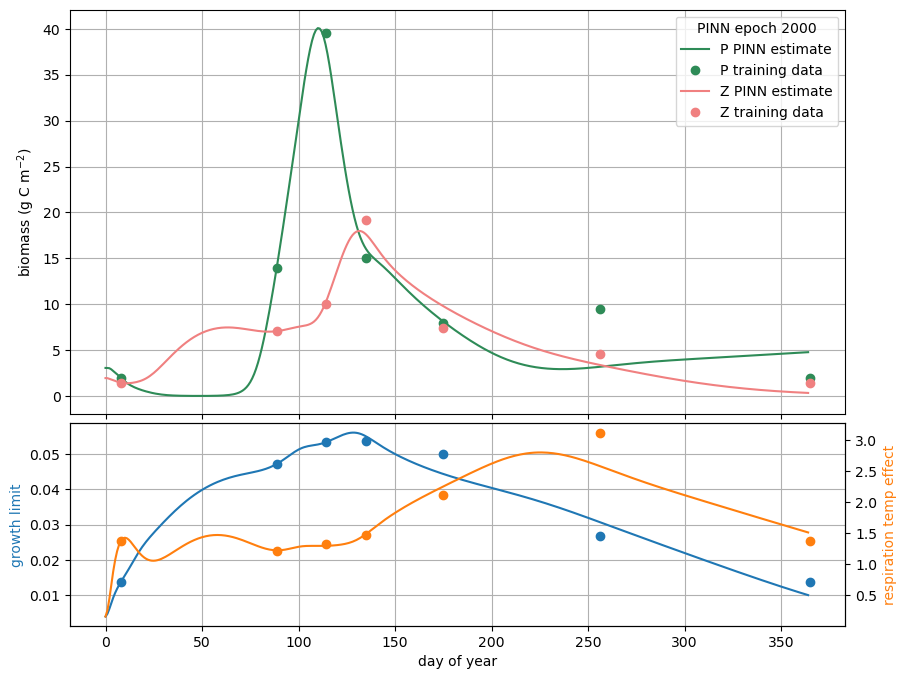

epoch 4000 (weight_dyn=0.0062): total loss: 0.079189( data loss: 0.078343 [98.9%],  dynamics loss: 0.000845 [1.1%])
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


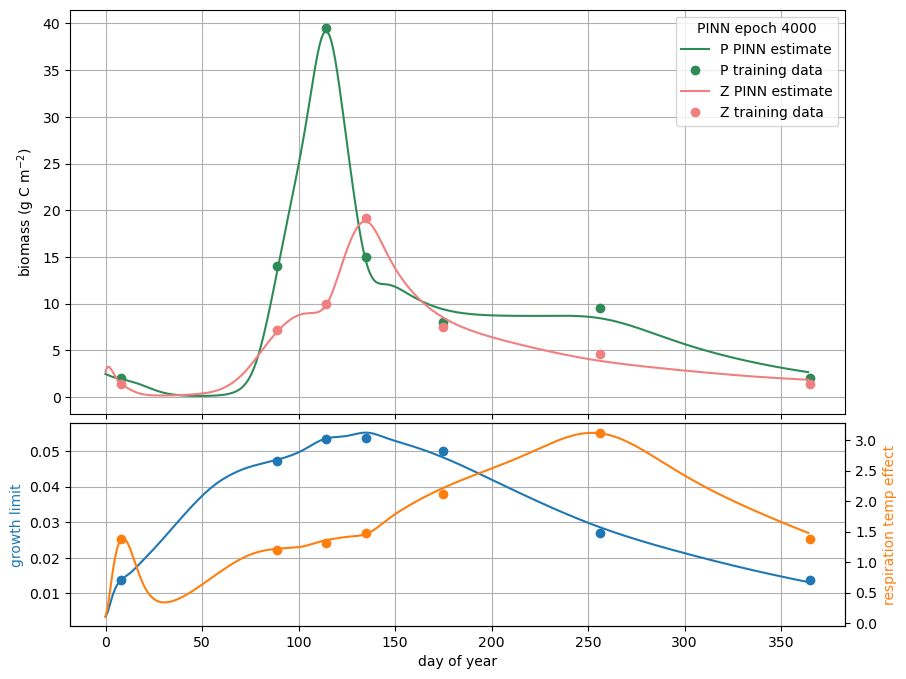

epoch 6000 (weight_dyn=0.0486): total loss: 0.042116( data loss: 0.034587 [82.1%],  dynamics loss: 0.007529 [17.9%])
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


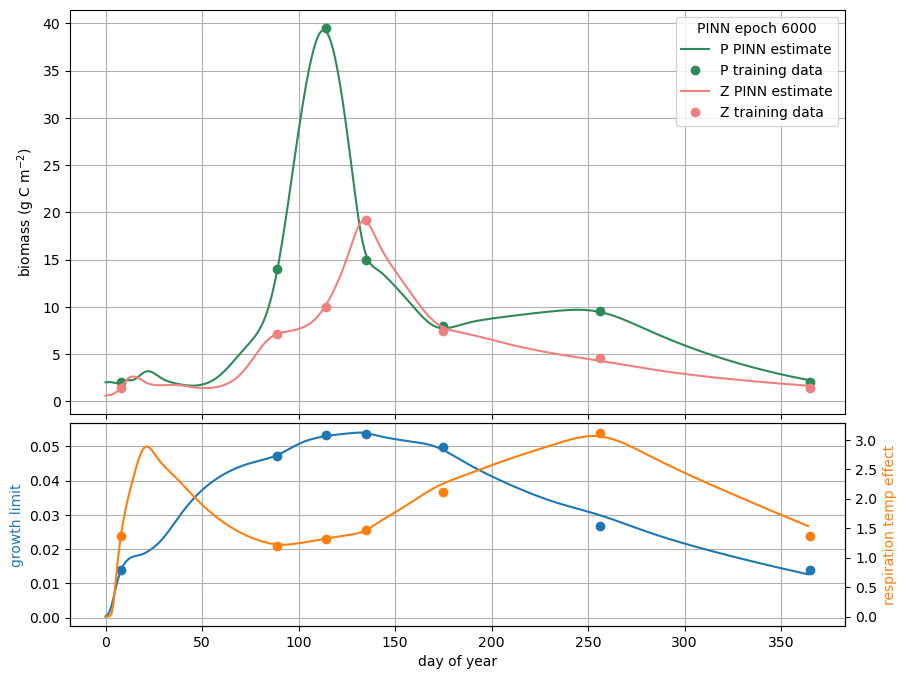

epoch 8000 (weight_dyn=0.3817): total loss: 0.026794( data loss: 0.009801 [36.6%],  dynamics loss: 0.016992 [63.4%])
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


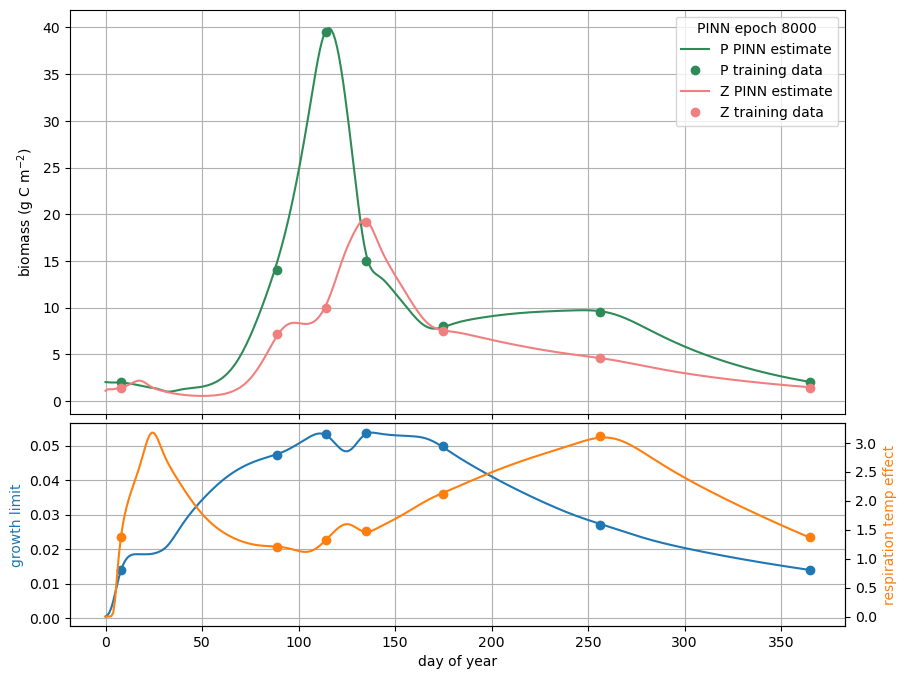

epoch 10000 (weight_dyn=3.0000): total loss: 0.097897( data loss: 0.039966 [40.8%],  dynamics loss: 0.057931 [59.2%])
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


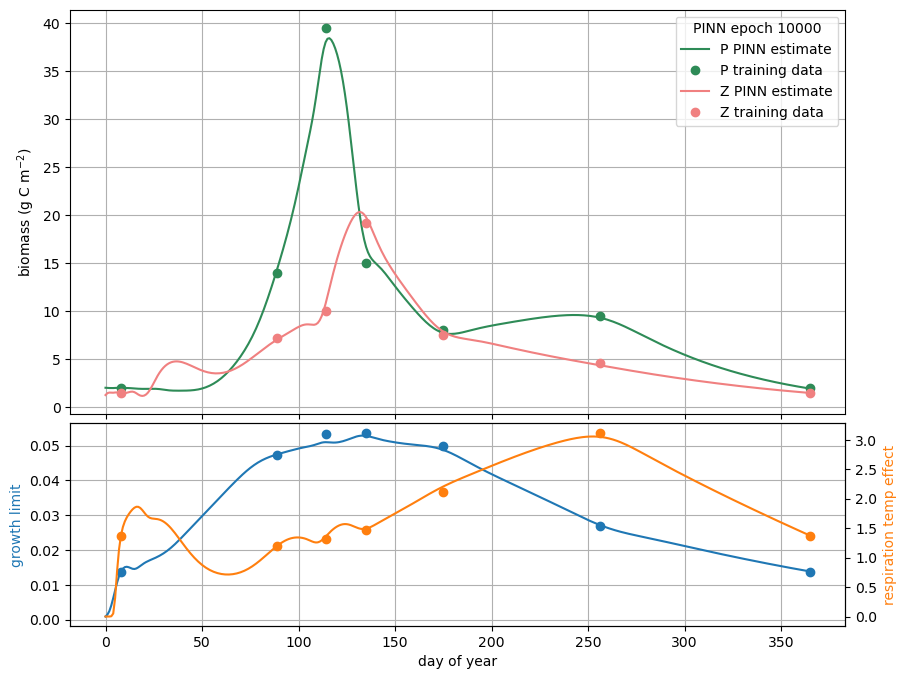

In [12]:
np.random.seed(seed)

# add noise to generate initial estimate of parameter values
parameters_ini = {p: parameters[p] * (1.0 + relerror_param * np.random.normal()) for p in parameters}

model_label = 'PINN'
print(f'starting {model_label} training...')
model_pinn, loss_history, parameters_pinn = train_pinn(parameters_ini, model_label=model_label,
                                                       estimate_parameters=estimate_parameters)

### Evaluating PINN results

In [13]:
for p in parameters:
    print(f'{p:>6s} initial value: {parameters[p]:8.4f}, estimated value: {parameters_pinn[p].numpy():8.4f}')

     p initial value:   2.5000, estimated value:   2.5000
    R0 initial value:   0.0175, estimated value:   0.0175
     g initial value:   0.0075, estimated value:   0.0075


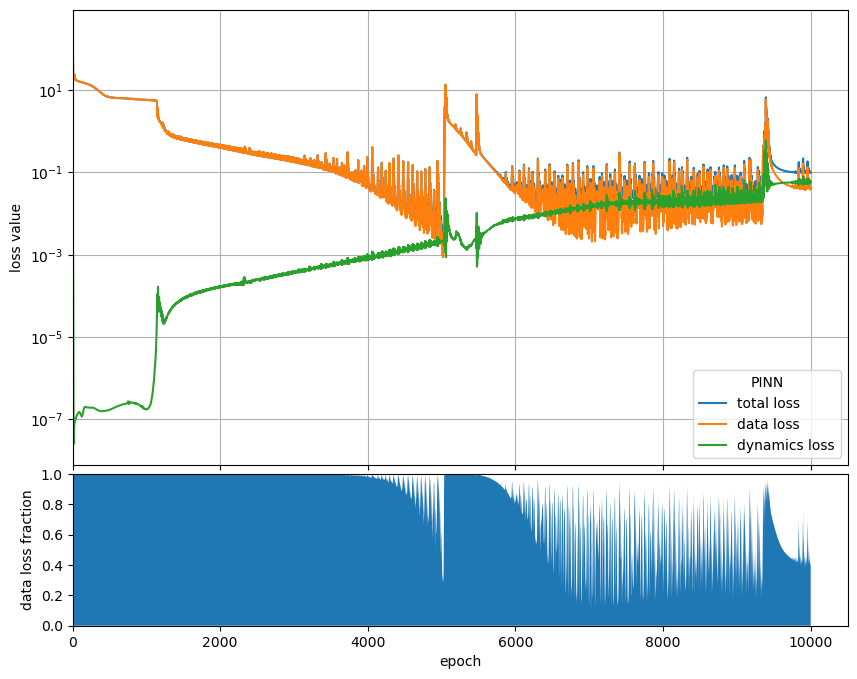

In [14]:
fig, axs = plt.subplots(nrows=2, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': (3, 1), 'hspace': 0.03})

ax = axs[0]
for key in loss_history:
    ax.plot(np.arange(1, len(loss_history[key])+1), loss_history[key], label=f'{key} loss')

ax.set(ylabel='loss value', yscale='log')
ax.grid(True)
ax.legend(title=model_label)
ax.set_xlim(left=0.0)

ax = axs[1]

ax.fill_between(np.arange(1, len(loss_history['total'])+1), 0, loss_history['data']/loss_history['total'])
ax.set(xlabel='epoch', ylabel='data loss fraction', ylim=(0, 1))
None